In [1]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy.ndimage import zoom as scipy_zoom
import scanpy as sc
import numpy as np
import squidpy as sq
from scipy.ndimage import gaussian_filter
import os
import pathlib
import urllib.request
import anndata as ad
from typing import Any
from os import PathLike # os.PathLike is fine for Python 3.6+
def _download(url: str, path: pathlib.Path) -> None:  # pragma: no cover
    """Download file from url to path."""
    try:
        # Ensure the parent directory exists
        path.parent.mkdir(parents=True, exist_ok=True)
        print(f"Downloading data from {url} to {path}...")
        urllib.request.urlretrieve(url, path)
        print("Download complete.")
    except urllib.error.URLError as e:
        raise RuntimeError(f"Failed to download from {url}. Error: {e}") from e
    except Exception as e:
        raise RuntimeError(f"An unexpected error occurred during download: {e}") from e
def _load_dataset_from_url(
    path: PathLike,
    file_type: str,
    backup_url: str,
    expected_shape: tuple[int, int],
    force_download: bool = False,
    **kwargs: Any,
) -> ad.AnnData:  # pragma: no cover
    """Load a dataset from a URL or a local path."""
    path_obj = pathlib.Path(os.path.expanduser(path))
    if force_download or not path_obj.is_file():
        _download(backup_url, path_obj)
    else:
        print(f"Found local copy of data at {path_obj}.")
    if file_type.lower() == "h5ad":
        adata = sc.read_h5ad(path_obj, **kwargs)
    else:
        raise ValueError(f"Unsupported file type: {file_type}. Only 'h5ad' is supported here.")
    if adata.shape != expected_shape:
        print(
            f"Warning: AnnData shape is {adata.shape}, but expected {expected_shape}. "
        )
    return adata
def mosta(
    path: PathLike = "~/.cache/moscot/mosta.h5ad", # Default cache path
    force_download: bool = False,
    **kwargs: Any,
) -> ad.AnnData:  # pragma: no cover
    """Preprocessed and extracted data as provided in :cite:`chen:22`.
    Includes embryo sections `E9.5`, `E2S1`, `E10.5`, `E2S1`, `E11.5`, `E1S2`.
    The :attr:`anndata.AnnData.X` is based on reprocessing of the counts data using
    :func:`scanpy.pp.normalize_total` and :func:`scanpy.pp.log1p`.
    Parameters
    ----------
    path
        Path where to save the file.
    force_download
        Whether to force-download the data.
    kwargs
        Keyword arguments for :func:`scanpy.read_h5ad`.
    Returns
    -------
    Annotated data object.
    """
    return _load_dataset_from_url(
        path,
        file_type="h5ad",
        backup_url="https://figshare.com/ndownloader/files/40569779",
        expected_shape=(54134, 2000),
        force_download=force_download,
        **kwargs,
    )



/cs/labs/mornitzan/ben.niasoff/new_venv/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/cs/labs/mornitzan/ben.niasoff/new_venv/lib/python3.11/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/cs/labs/mornitzan/ben.niasoff/new_venv/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
adata = mosta() # Changed from: adata = datasets.mosta()
adata.obs["time"] = adata.obs["time"].astype("category")
adata
adata_e11_5 = adata[adata.obs["timepoint"] == "E11.5"].copy()
seed_data = adata[adata.obs["timepoint"] == "E9.5"].copy()
sc.pp.filter_genes(adata_e11_5, min_counts=300)
sq.gr.spatial_neighbors(adata_e11_5, key_added='spatial')
sq.gr.spatial_autocorr(
    adata_e11_5,
    genes=adata_e11_5.var_names,  # calculate for all genes
    mode='moran',
    n_jobs=1,  # Adjust the number of parallel jobs if needed
)

len(adata_e11_5.var_names)

Found local copy of data at /cs/usr/ben.niasoff/.cache/moscot/mosta.h5ad.


809

In [3]:

# Function to prepare gene expression target
def prepare_gene_expression_target(adata_e11_5, gene_names, target_size=1000):
    """
    Convert spatial gene expression data to a target image for NCA training.
    """
    # Get spatial coordinates and gene expression
    spatial_coords = adata_e11_5.obsm['spatial']
    all_gene_expression = []
    for gene_name in gene_names:
        if isinstance(adata_e11_5.X, np.ndarray):
            gene_expression = adata_e11_5[:, gene_name].X.flatten()
        else:
            gene_expression = adata_e11_5[:, gene_name].X.toarray().flatten()
        all_gene_expression.append(gene_expression)
    all_gene_expression = np.vstack(all_gene_expression).T # Shape (n_obs, n_genes)
  
    # Normalize coordinates to [0, target_size-1]
    coords_norm = spatial_coords.copy()
    coords_norm[:, 0] = (coords_norm[:, 0] - coords_norm[:, 0].min()) / (coords_norm[:, 0].max() - coords_norm[:, 0].min()) * (target_size - 1)
    coords_norm[:, 1] = (coords_norm[:, 1] - coords_norm[:, 1].min()) / (coords_norm[:, 1].max() - coords_norm[:, 1].min()) * (target_size - 1)

    # Create target image
    target_img = np.zeros((target_size, target_size, len(gene_names)), dtype=np.float32)

    for i, (x, y) in enumerate(coords_norm.astype(int)):
        if 0 <= x < target_size and 0 <= y < target_size:
            # RGB channels represent gene expression intensity
            for c in range(len(gene_names)):
                target_img[y, x, c] = all_gene_expression[i, c]

    return target_img # Return both target_img and scaler

def create_nca_input(
    adata_e11_5: ad.AnnData,
    genes: list[str],
    hidden_channels: int = 100,
    target_size: int = 100
) -> np.ndarray:
    """
    Uses prepare_gene_expression_target to create the RGB image, then adds
    alpha and latent channels, and normalizes the first 3 channels.
    Returns the final (H, W, C) numpy array for NCA training.
    """

    # Generate the base RGB image from gene expressions
    target_rgb = prepare_gene_expression_target(adata_e11_5, genes, target_size)
    
    h, w = target_rgb.shape[:2]
    alpha = (target_rgb.sum(-1, keepdims=True) > 0).astype(np.float32)
    latent = np.zeros((h, w, hidden_channels), dtype=np.float32)

    # Concatenate all channels: RGB + alpha + latent
    target_img_np = np.concatenate([target_rgb, alpha, latent], axis=-1)

    # Normalize only the first 3 channels (RGB)
    for c in range(3):
        ch = target_img_np[..., c]
        target_img_np[..., c] = (ch - ch.min()) / (ch.max() - ch.min() + 1e-8)
    
    return target_img_np

In [4]:


import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.optim.lr_scheduler as sched
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import random


class CAModel(nn.Module):
    def __init__(self, n_genes=10, hidden_channels=10, fire_rate=0.5, alive_threshold=0.1):
        super(CAModel, self).__init__()
        self.n_genes = n_genes
        self.hidden_channels = hidden_channels
        self.channel_n = n_genes + 1 + hidden_channels  # genes + alpha + hidden
        self.fire_rate = fire_rate
        self.alive_thr = alive_threshold
        
        # Define fixed perception kernels (identity, Sobel X, Sobel Y)
        identity_kernel_vals = torch.tensor([[0., 0., 0.], [0., 1., 0.], [0., 0., 0.]], dtype=torch.float32)
        sobel_x_kernel_vals = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]], dtype=torch.float32) / 8.0
        sobel_y_kernel_vals = sobel_x_kernel_vals.T # Transpose of Sobel X is Sobel Y
        
        # Expand kernels for depthwise-like application for each channel
        k_identity = identity_kernel_vals.unsqueeze(0).unsqueeze(0).repeat(self.channel_n, 1, 1, 1)
        k_dx = sobel_x_kernel_vals.unsqueeze(0).unsqueeze(0).repeat(self.channel_n, 1, 1, 1)
        k_dy = sobel_y_kernel_vals.unsqueeze(0).unsqueeze(0).repeat(self.channel_n, 1, 1, 1)
        
        # Concatenate to form the full perception kernel
        full_perception_kernel = torch.cat([k_identity, k_dx, k_dy], dim=0)
        self.register_buffer('perception_kernel', full_perception_kernel)
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(3*self.channel_n, 128, 1)
        self.conv2 = nn.Conv2d(128, self.channel_n, 1, bias=False)
        nn.init.zeros_(self.conv2.weight)    

    def alive(self, x):
        # Alpha channel is at position n_genes (after all gene channels)
        alpha_idx = self.n_genes
        a = x[:, alpha_idx:alpha_idx+1]
        return F.max_pool2d((a > self.alive_thr).float(), 3, 1, 1)

    def forward(self, x, fire_rate=None, step_size=1.0):
        # Perceive the environment
        pre_alive = self.alive(x)
        y = self.perceive(x)
        
        # Apply ReLU after the first convolution, then the second convolution
        dx = self.conv2(F.relu(self.conv1(y))) * step_size
        
        if fire_rate is None:
            fire_rate = self.fire_rate
        update_mask = (torch.rand_like(x[:, :1]) <= fire_rate).float()
        x = x + dx * update_mask  
        
        post_alive = self.alive(x)
        life_mask = (pre_alive * post_alive) 
        x = x * life_mask  # clear "dead" cells
        
        # Clamp gene expression channels and alpha to [0,1]
        gene_alpha_end = self.n_genes + 1
        x[:, :gene_alpha_end].clamp_(0.0, 1.0)
        # Clamp hidden channels to [-10, 10]
        x[:, gene_alpha_end:].clamp_(-10.0, 10.0)
        
        return x
    
    def perceive(self, x):
        y = F.conv2d(x, self.perception_kernel, stride=1, padding=1, groups=self.channel_n)
        return y
# Check GPU availability and move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
def create_nca_input(
    adata_e11_5: ad.AnnData,
    genes: list[str],
    hidden_channels: int = 100,
    target_size: int = 100
) -> np.ndarray:
    """
    Uses prepare_gene_expression_target to create the RGB image, then adds
    alpha and latent channels, and normalizes the first 3 channels.
    Returns the final (H, W, C) numpy array for NCA training.
    """

    # Generate the base RGB image from gene expressions
    target_rgb = prepare_gene_expression_target(adata_e11_5, genes, target_size)
    
    h, w = target_rgb.shape[:2]
    alpha = (target_rgb.sum(-1, keepdims=True) > 0).astype(np.float32)
    latent = np.zeros((h, w, hidden_channels), dtype=np.float32)

    # Concatenate all channels: RGB + alpha + latent
    target_img_np = np.concatenate([target_rgb, alpha, latent], axis=-1)

    # Normalize only the first 3 channels (RGB)
    for c in range(len(genes)):
        ch = target_img_np[..., c]
        target_img_np[..., c] = (ch - ch.min()) / (ch.max() - ch.min() + 1e-8)
    
    return target_img_np

In [6]:
moran_df = adata_e11_5.uns['moranI']
moran_df_sorted = moran_df.sort_values("I", ascending=False)
available_genes_in_seed = set(seed_data.var_names)
filtered_moran_genes = [gene for gene in moran_df_sorted.index if gene in available_genes_in_seed]

n_genes = min(1000, len(filtered_moran_genes))
hidden_channels = 0  # Number of latent channels
genes = filtered_moran_genes[:n_genes]          
      
target_img_np =  create_nca_input(
    adata_e11_5,
    genes=genes,
    hidden_channels=hidden_channels,  # Number of latent channels
    target_size=100       # Size of the target image
)

seed = create_nca_input(
    seed_data,
    genes=genes,
    hidden_channels=hidden_channels,  # Number of latent channels
    target_size=100       # Size of the target image
)

print(n_genes)

809


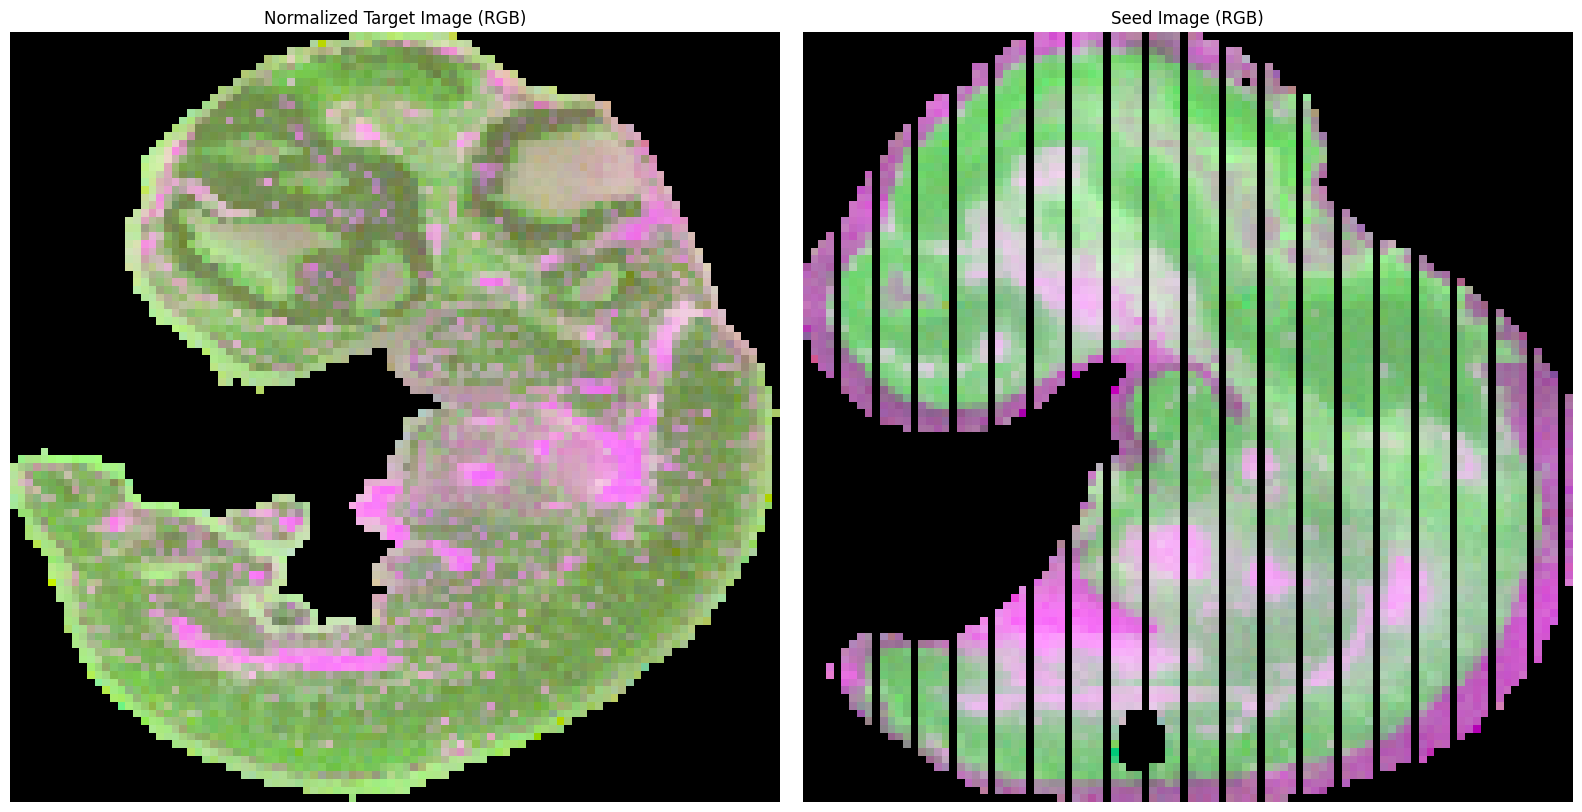

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(target_img_np[..., :3])
axes[0].set_title("Normalized Target Image (RGB)")
axes[0].axis("off")

axes[1].imshow(seed[..., :3])
axes[1].set_title("Seed Image (RGB)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:


model = CAModel(
    n_genes=n_genes, 
    hidden_channels=hidden_channels
).to(device)
# Generate random seed for the cellular automaton
h, w = target_img_np.shape[:2] # h, w from the actual target image

target_tensor = torch.tensor(target_img_np, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)  # Move to GPU

seed_tensor = torch.tensor(seed, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)



base_lr   = 2e-3
t_warm    = 200     # steps 0 … 199
t_plateau = 1000    # steps 200 … 1999  (plateau ends at 2 000)
t_total   = 2000    # training ends at 5 000

optimizer = optim.Adam(model.parameters(), lr=base_lr)

# --- phase 1: warm-up -------------------------------------------------
warmup_sched = sched.LinearLR(
    optimizer,
    start_factor=0.1,         # 0.1 × base_lr → base_lr
    end_factor=1.0,
    total_iters=t_warm
)

# --- phase 2: flat plateau -------------------------------------------
plateau_sched = sched.ConstantLR(
    optimizer,
    factor=1.0,               # keep at base_lr
    total_iters=t_plateau - t_warm
)

# --- phase 3: cosine decay -------------------------------------------
cosine_sched = sched.CosineAnnealingLR(
    optimizer,
    T_max=t_total - t_plateau,  # number of decay steps
    eta_min=base_lr * 0.1
)

# Chain them together
scheduler = sched.SequentialLR(
    optimizer,
    schedulers=[warmup_sched, plateau_sched, cosine_sched],
    milestones=[t_warm, t_plateau]       # step indices where we switch
)




num_epochs = 2000 # Increased epochs, adjust as needed
loss_log = []
for epoch in range(num_epochs):
    current_state = seed_tensor.clone() # Start from seed each epoch for "growing"
    for _ in range(random.randint(100, 150)):
        current_state = model(current_state) # Evolve the state
    optimizer.zero_grad()
    loss_channels = model.n_genes + 1  # genes + alpha
    loss = F.mse_loss(current_state[:, :loss_channels], target_tensor[:, :loss_channels])
    # Backpropagation
    loss.backward()
    for p in model.parameters():
        if p.grad is not None:
            g_norm = p.grad.data.norm()
            if g_norm > 1:
                p.grad.data /= g_norm 


    optimizer.step()
    scheduler.step() 
    loss_log.append(loss.item())
    # Print loss
    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}')




Loss (all genes): 0.0072
Loss (masked genes): 0.0072


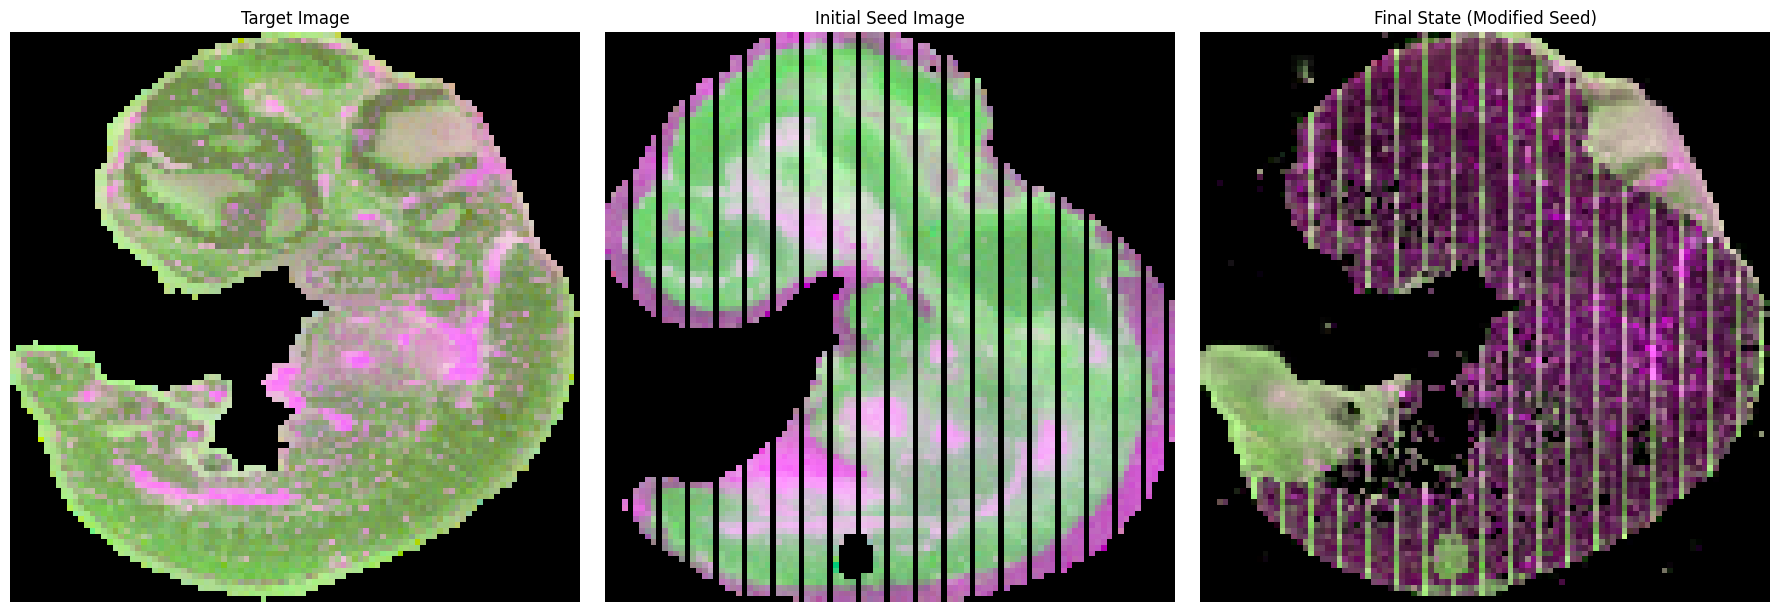

In [15]:


def masked_mse_loss(output, target, mask):
    """
    Calculates MSE loss only for the masked elements.
    """
    masked_output = output * mask
    masked_target = target * mask
    return F.mse_loss(masked_output, masked_target)

# Create a modified seed with the first 100 genes set to zero
modified_seed = seed_tensor.clone()
modified_seed[:, :10] = 0.0  # Set first 100 channels to zero

# Perform inference with the modified seed
model.eval()  # Set the model to evaluation mode
with torch.no_grad():  # Disable gradient calculation during inference
    final_state = modified_seed.clone()
    for _ in range(150):  # Run for a fixed number of steps
        final_state = model(final_state)

# Calculate the loss
loss_all_genes = F.mse_loss(final_state[:, :n_genes], target_tensor[:, :n_genes]).item()

# Create a mask for the non-zero genes in the original seed
gene_mask = (seed_tensor[:, :n_genes].abs().sum(dim=(2, 3), keepdim=True) > 0).float()

# Calculate the masked loss
loss_masked_genes = masked_mse_loss(final_state[:, :n_genes], target_tensor[:, :n_genes], gene_mask).item()

print(f"Loss (all genes): {loss_all_genes:.4f}")
print(f"Loss (masked genes): {loss_masked_genes:.4f}")

# Visualize the results (optional)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot the target image
axes[0].imshow(target_tensor[0, :3].cpu().permute(1, 2, 0).clamp(0, 1))
axes[0].set_title("Target Image")
axes[0].axis("off")

# Plot the initial seed image
axes[1].imshow(seed_tensor[0, :3].cpu().permute(1, 2, 0).clamp(0, 1))
axes[1].set_title("Initial Seed Image")
axes[1].axis("off")

# Plot the final state image
axes[2].imshow(final_state[0, :3].cpu().permute(1, 2, 0).clamp(0, 1))
axes[2].set_title("Final State (Modified Seed)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

Loss (all genes, first 10 zeroed): 0.0073
Loss (masked genes, first 10 zeroed): 0.0073
Loss (all genes, last 10 zeroed): 0.0050
Loss (masked genes, last 10 zeroed): 0.0050


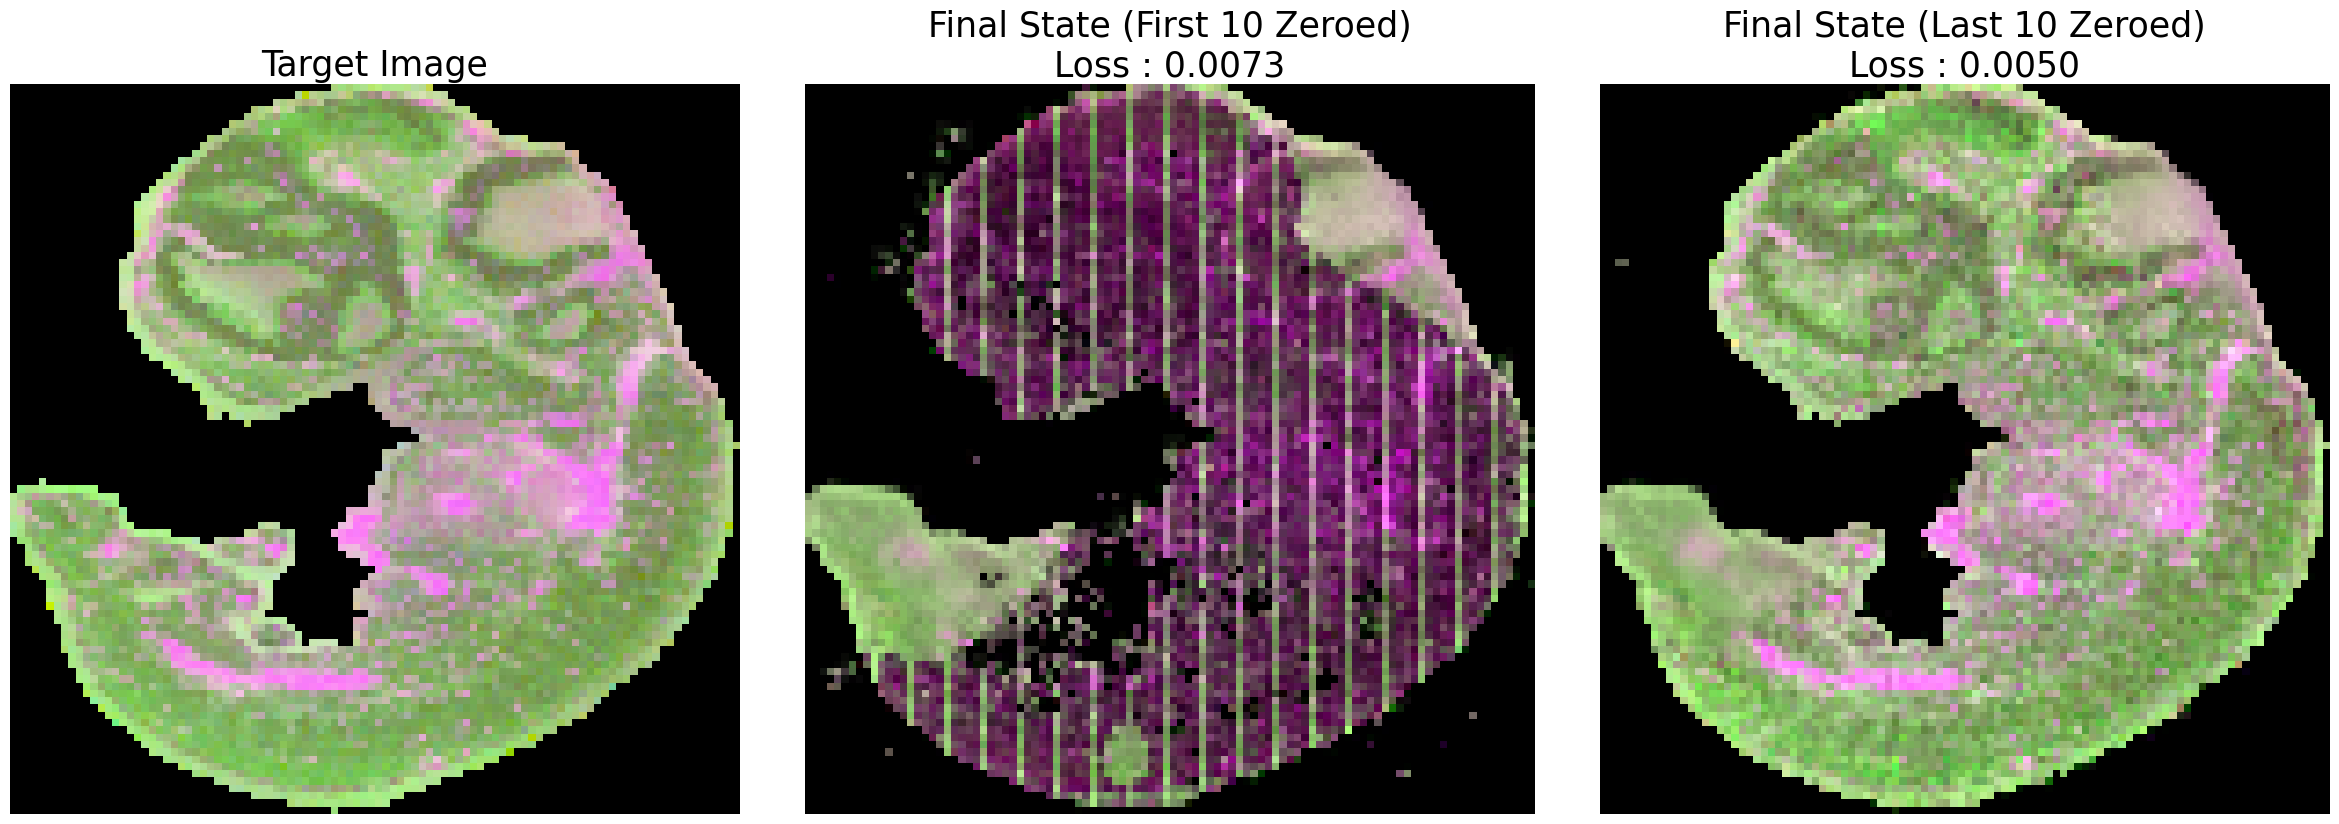

In [19]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have defined:
# - model (your CAModel)
# - target_tensor (your target tensor on the correct device)
# - seed_tensor (your initial seed tensor on the correct device)
# - n_genes (number of genes)
# - device (cuda or cpu)

def masked_mse_loss(output, target, mask):
    """
    Calculates MSE loss only for the masked elements.
    """
    masked_output = output * mask
    masked_target = target * mask
    return F.mse_loss(masked_output, masked_target)

# Create modified seeds
modified_seed_first = seed_tensor.clone()
modified_seed_first[:, :10] = 0.0  # Set first 10 channels to zero

modified_seed_last = seed_tensor.clone()
modified_seed_last[:, -11:-1] = 0.0  # Set last 10 gene channels to zero, preserving alpha

# Perform inference with the modified seeds
model.eval()  # Set the model to evaluation mode
with torch.no_grad():  # Disable gradient calculation during inference
    final_state_first = modified_seed_first.clone()
    for _ in range(200):  # Run for a fixed number of steps
        final_state_first = model(final_state_first)

    final_state_last = modified_seed_last.clone()
    for _ in range(200):  # Run for a fixed number of steps
        final_state_last = model(final_state_last)

# Calculate the losses
loss_all_genes_first = F.mse_loss(final_state_first[:, :n_genes], target_tensor[:, :n_genes]).item()
loss_all_genes_last = F.mse_loss(final_state_last[:, :n_genes], target_tensor[:, :n_genes]).item()

# Create a mask for the non-zero genes in the original seed
gene_mask = (seed_tensor[:, :n_genes].abs().sum(dim=(2, 3), keepdim=True) > 0).float()

# Calculate the masked losses
loss_masked_genes_first = masked_mse_loss(final_state_first[:, :n_genes], target_tensor[:, :n_genes], gene_mask).item()
loss_masked_genes_last = masked_mse_loss(final_state_last[:, :n_genes], target_tensor[:, :n_genes], gene_mask).item()

print(f"Loss (all genes, first 10 zeroed): {loss_all_genes_first:.4f}")
print(f"Loss (masked genes, first 10 zeroed): {loss_masked_genes_first:.4f}")
print(f"Loss (all genes, last 10 zeroed): {loss_all_genes_last:.4f}")
print(f"Loss (masked genes, last 10 zeroed): {loss_masked_genes_last:.4f}")

# Visualize the results
fig, axes = plt.subplots(1, 3, figsize=(24, 8))  # Increased figure size
title_size = 25  # Adjust title size for better visibility
# Plot the target image
axes[0].imshow(target_tensor[0, :3].cpu().permute(1, 2, 0).clamp(0, 1))
axes[0].set_title("Target Image", fontsize=title_size)
axes[0].axis("off")

# Plot the final state image (first 10 zeroed)
axes[1].imshow(final_state_first[0, :3].cpu().permute(1, 2, 0).clamp(0, 1))
axes[1].set_title(f"Final State (First 10 Zeroed)\nLoss : {loss_all_genes_first:.4f}", fontsize=title_size)
axes[1].axis("off")

# Plot the final state image (last 10 zeroed)
axes[2].imshow(final_state_last[0, :3].cpu().permute(1, 2, 0).clamp(0, 1))
axes[2].set_title(f"Final State (Last 10 Zeroed)\nLoss : {loss_all_genes_last:.4f}", fontsize=title_size)
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [41]:
import torch
import torch.nn.functional as F
import numpy as np

def gene_ablation_loss(model, target_tensor, seed_tensor, n_genes, gene_mask, device, genes, num_steps=200):
    """
    Calculates the loss after ablating each individual gene in the seed.

    Args:
        model: The trained NCA model.
        target_tensor: The target tensor.
        seed_tensor: The initial seed tensor.
        n_genes: The number of genes.
        gene_mask: Mask of non-zero genes in original seed
        device: Device (CPU or GPU).
        genes: A list of gene names corresponding to the gene indices.
        num_steps: Number of inference steps.

    Returns:
        A list of tuples, where each tuple contains the gene name and the
        corresponding loss (all genes), sorted by ascending loss.
    """

    model.eval()  # Set the model to evaluation mode
    gene_losses = []

    with torch.no_grad():  # Disable gradient calculation during inference
        for i in range(n_genes):
            modified_seed = seed_tensor.clone()
            modified_seed[:, i:i+1] = 0.0  # Ablate the i-th gene

            final_state = modified_seed.clone()
            for _ in range(num_steps):
                final_state = model(final_state)

            loss_all_genes = F.mse_loss(final_state[:, :n_genes], target_tensor[:, :n_genes]).item()
            gene_losses.append((genes[i], loss_all_genes))  # Store gene name instead of index

    # Sort genes by ascending loss
    gene_losses.sort(key=lambda x: x[1])
    return gene_losses

# Example usage:
# Assuming you have defined:
# - model (your CAModel)
# - target_tensor (your target tensor on the correct device)
# - seed_tensor (your initial seed tensor on the correct device)
# - n_genes (number of genes)
# - device (cuda or cpu)
# - genes (list of gene names)

# Create a mask for the non-zero genes in the original seed
gene_mask = (seed_tensor[:, :n_genes].abs().sum(dim=(2, 3), keepdim=True) > 0).float()

sorted_genes_by_loss = gene_ablation_loss(
    model=model,
    target_tensor=target_tensor,
    seed_tensor=seed_tensor,
    n_genes=n_genes,
    gene_mask=gene_mask,
    device=device,
    genes=genes  # Pass the list of gene names
)


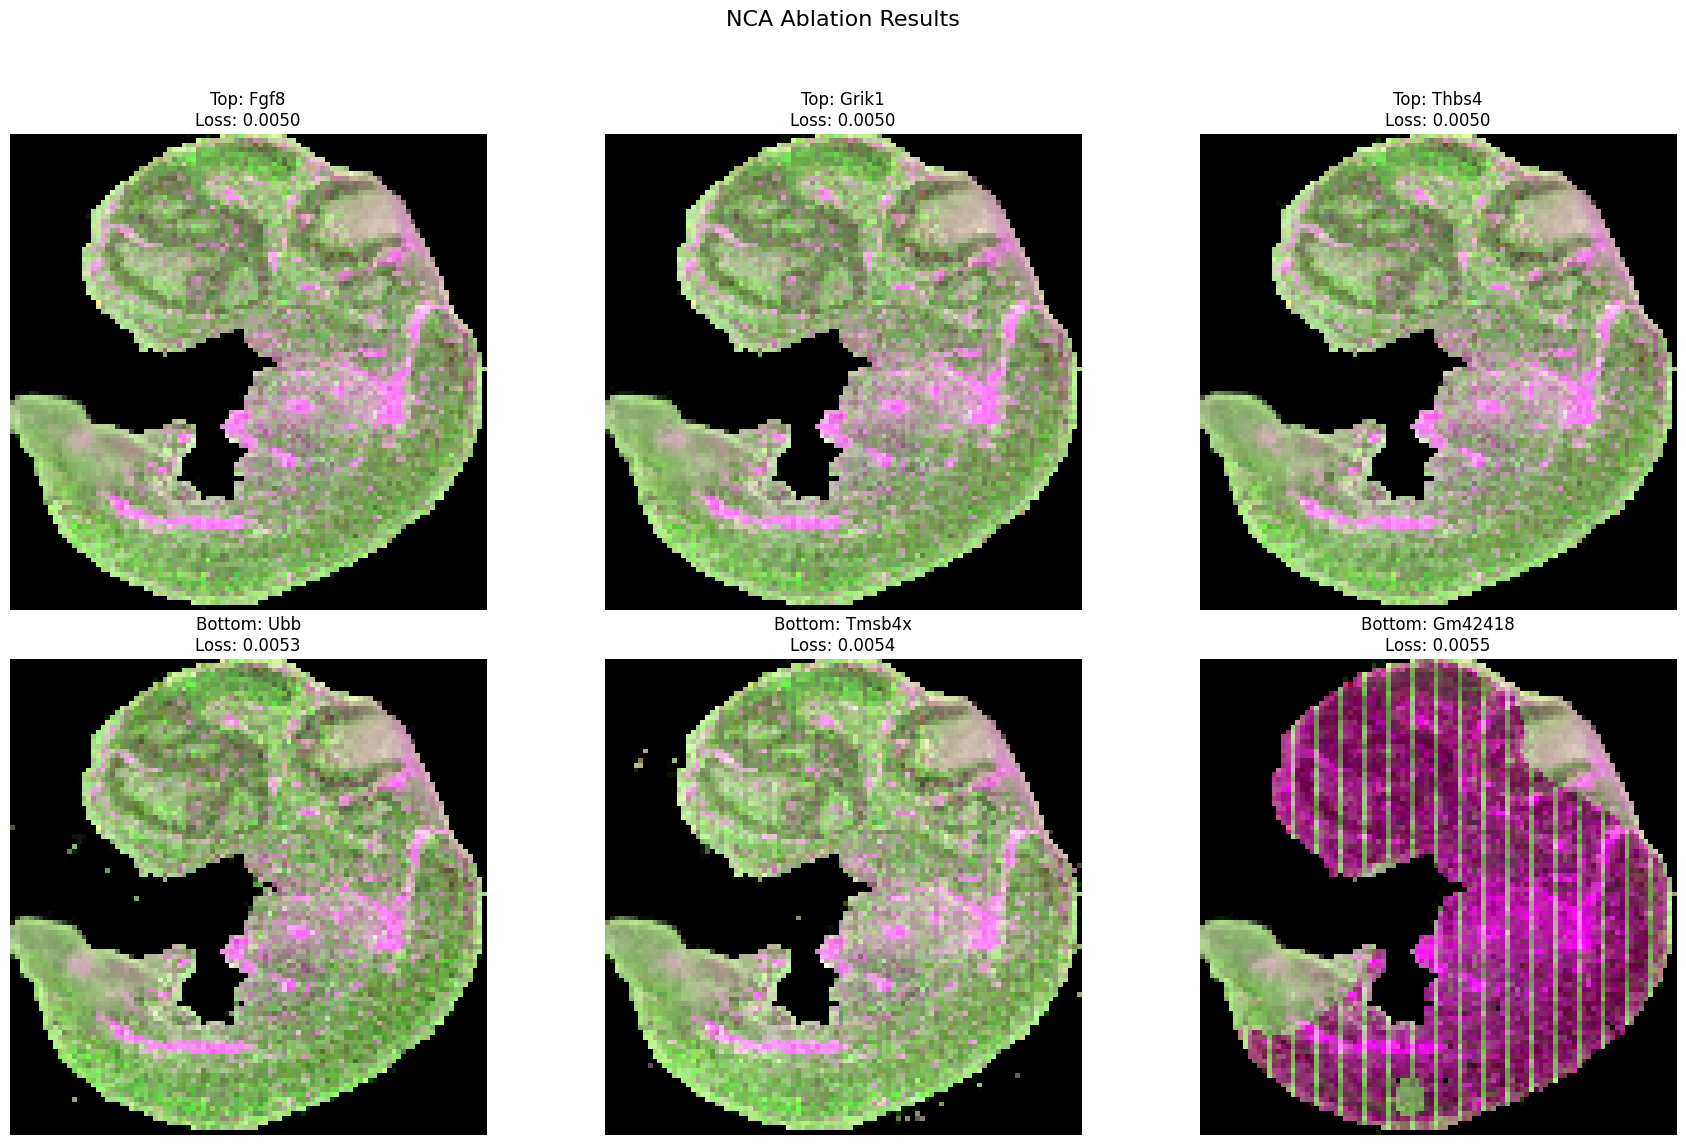

In [42]:


def plot_ablation_results(model, target_tensor, seed_tensor, n_genes, genes, device, sorted_genes_by_loss, num_steps=150):
    """
    Plots the final state of the NCA after ablating the top 3 and bottom 3 genes based on loss.

    Args:
        model: The trained NCA model.
        target_tensor: The target tensor.
        seed_tensor: The initial seed tensor.
        n_genes: The number of genes.
        genes: List of gene names.
        device: Device (CPU or GPU).
        sorted_genes_by_loss: List of tuples (gene_name, loss) sorted by ascending loss.
        num_steps: Number of inference steps for ablation.
    """

    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():  # Disable gradient calculation

        # Get top 3 and bottom 3 genes
        top_genes = sorted_genes_by_loss[:3]
        bottom_genes = sorted_genes_by_loss[-3:]

        # Create subplots
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))  # Adjust figsize as needed
        fig.suptitle("NCA Ablation Results", fontsize=16)

        # Function to perform ablation and get final state
        def ablate_and_get_final_state(gene_name):
            gene_index = genes.index(gene_name)
            modified_seed = seed_tensor.clone()
            modified_seed[:, gene_index:gene_index+1] = 0.0  # Ablate the gene

            final_state = modified_seed.clone()
            for _ in range(num_steps):
                final_state = model(final_state)
            return final_state

        # Plot top 3 genes
        for i, (gene_name, loss) in enumerate(top_genes):
            final_state = ablate_and_get_final_state(gene_name)
            img = final_state[0, :3].cpu().permute(1, 2, 0).clamp(0, 1).numpy()
            axes[0, i].imshow(img)
            axes[0, i].set_title(f"Top: {gene_name}\nLoss: {loss:.4f}")
            axes[0, i].axis("off")

        # Plot bottom 3 genes
        for i, (gene_name, loss) in enumerate(bottom_genes):
            final_state = ablate_and_get_final_state(gene_name)
            img = final_state[0, :3].cpu().permute(1, 2, 0).clamp(0, 1).numpy()
            axes[1, i].imshow(img)
            axes[1, i].set_title(f"Bottom: {gene_name}\nLoss: {loss:.4f}")
            axes[1, i].axis("off")

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for suptitle
        plt.show()

# Example Usage (assuming you have model, target_tensor, seed_tensor, n_genes, genes, device, sorted_genes_by_loss defined):
plot_ablation_results(model, target_tensor, seed_tensor, n_genes, genes, device, sorted_genes_by_loss)

In [43]:
for gene in genes[1:10]:
    moran_i = moran_df.loc[gene, "I"]
    print(f"Gene: {gene}, Moran's I: {moran_i:.4f}")



Gene: Gm42418, Moran's I: 0.8553
Gene: Hbb-bh1, Moran's I: 0.8371
Gene: Hba-x, Moran's I: 0.8234
Gene: Hba-a1, Moran's I: 0.8180
Gene: Myl7, Moran's I: 0.7849
Gene: Hba-a2, Moran's I: 0.7805
Gene: Tuba1a, Moran's I: 0.7638
Gene: Afp, Moran's I: 0.7629
Gene: Myl2, Moran's I: 0.7629


In [44]:
import pandas as pd

def print_moran_i(genes, moran_df, sorted_genes_by_loss=None):
    """
    Prints the Moran's I and ablation loss values for a list of genes.

    Args:
        genes (list): List of gene names.
        moran_df (pd.DataFrame): DataFrame containing Moran's I results, indexed by gene name.
        sorted_genes_by_loss (list, optional): List of tuples (gene, ablation_loss) sorted by ablation loss. Defaults to None.
    """
    print("Moran's I and Ablation Loss values:")
    for gene in genes:
        if gene in moran_df.index:
            moran_i = moran_df.loc[gene, "I"]  # Access 'I' column
            ablation_loss = None
            if sorted_genes_by_loss:
                # Find the ablation loss for the current gene
                for g, loss in sorted_genes_by_loss:
                    if g == gene:
                        ablation_loss = loss
                        break

            if ablation_loss is not None:
                print(f"Gene: {gene}, Moran's I: {moran_i:.4f}, Ablation Loss: {ablation_loss:.4f}")
            else:
                print(f"Gene: {gene}, Moran's I: {moran_i:.4f}, Ablation Loss: Not Found")
        else:
            print(f"Gene: {gene} not found in Moran's I results.")

# Assuming sorted_genes_by_loss is already calculated
top_genes = [gene_name for gene_name, loss in sorted_genes_by_loss[:5]]
bottom_genes = [gene_name for gene_name, loss in sorted_genes_by_loss[-5:]]

print("Top 5 Ablation Genes:")
print_moran_i(top_genes, adata_e11_5.uns['moranI'], sorted_genes_by_loss)
print()
print("lowest Moran's I values:")
for gene in moran_df.nsmallest(5, 'I').index:
    print(f"Gene: {gene}, Moran's I: {moran_df.loc[gene, 'I']:.4f}")

print("\nBottom 5 Ablation Genes:")
print_moran_i(bottom_genes, adata_e11_5.uns['moranI'], sorted_genes_by_loss)
print()
print("Highest Moran's I values:")
for gene in moran_df.nlargest(5, 'I').index:
    print(f"Gene: {gene}, Moran's I: {moran_df.loc[gene, 'I']:.4f}")

Top 5 Ablation Genes:
Moran's I and Ablation Loss values:
Gene: Fgf8, Moran's I: 0.2944, Ablation Loss: 0.0050
Gene: Grik1, Moran's I: 0.0287, Ablation Loss: 0.0050
Gene: Thbs4, Moran's I: 0.0845, Ablation Loss: 0.0050
Gene: Tubb4a, Moran's I: 0.3133, Ablation Loss: 0.0050
Gene: Fga, Moran's I: 0.2049, Ablation Loss: 0.0050

lowest Moran's I values:
Gene: Pkhd1, Moran's I: -0.0002
Gene: Col24a1, Moran's I: 0.0034
Gene: Vps37b, Moran's I: 0.0041
Gene: Hyal1, Moran's I: 0.0044
Gene: Rims1, Moran's I: 0.0059

Bottom 5 Ablation Genes:
Moran's I and Ablation Loss values:
Gene: Hbb-bh1, Moran's I: 0.8371, Ablation Loss: 0.0052
Gene: Cdk8, Moran's I: 0.7592, Ablation Loss: 0.0052
Gene: Ubb, Moran's I: 0.5891, Ablation Loss: 0.0053
Gene: Tmsb4x, Moran's I: 0.6724, Ablation Loss: 0.0054
Gene: Gm42418, Moran's I: 0.8553, Ablation Loss: 0.0055

Highest Moran's I values:
Gene: Hbb-y, Moran's I: 0.8616
Gene: Gm42418, Moran's I: 0.8553
Gene: Hbb-bh1, Moran's I: 0.8371
Gene: Hba-x, Moran's I: 0.8234


In [31]:
moran_df = adata_e11_5.uns['moranI']
min_moran_i = moran_df['I'].min()
max_moran_i = moran_df['I'].max()

print(f"Minimum Moran's I: {min_moran_i:.4f}")
print(f"Maximum Moran's I: {max_moran_i:.4f}")

Minimum Moran's I: -0.0002
Maximum Moran's I: 0.8616


In [ ]:
%matplotlib inline
import matplotlib.animation as animation
from IPython.display import HTML
from sklearn.decomposition import PCA

inference_seed = seed_tensor.clone().to(device)  # Global placeholder

# Set up PCA for consistent transformation
initial_gene_data = seed_tensor[0, :n_genes].detach().cpu().numpy().reshape(n_genes, -1).T
initial_gene_data_filtered = initial_gene_data[initial_gene_data.sum(axis=1) > 0]
pca = PCA(n_components=2)
pca.fit(initial_gene_data_filtered)

# Create subplot with 1x2 layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Left plot: spatial image
im1 = ax1.imshow(np.zeros((100, 100, 3)), animated=True)
ax1.set_title("NCA Evolution (RGB)")
ax1.axis("off")

# Right plot: PCA scatter
ax2.set_xlim(-5, 5)  # Adjust based on your data range
ax2.set_ylim(-5, 5)
ax2.set_title("Gene Expression PCA")
ax2.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
ax2.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
scat = ax2.scatter([], [], alpha=0.6, s=1, animated=True)

def init():
    global inference_seed
    inference_seed = seed_tensor.clone().to(device)  # Reset to original seed
    rgb = inference_seed[0, :3].detach().cpu().numpy().transpose(1, 2, 0)
    im1.set_array(rgb)
    
    # Initialize PCA plot
    gene_data = inference_seed[0, :n_genes].detach().cpu().numpy().reshape(n_genes, -1).T
    gene_data_filtered = gene_data[gene_data.sum(axis=1) > 0]
    if len(gene_data_filtered) > 0:
        pca_coords = pca.transform(gene_data_filtered)
        scat.set_offsets(pca_coords)
    
    return [im1, scat]

def update(frame):
    global inference_seed
    inference_seed = model(inference_seed)
    
    # Update spatial image
    rgb = inference_seed[0, :3].detach().cpu().numpy().transpose(1, 2, 0)
    im1.set_array(rgb)
    
    # Update PCA plot
    gene_data = inference_seed[0, :n_genes].detach().cpu().numpy().reshape(n_genes, -1).T
    gene_data_filtered = gene_data[gene_data.sum(axis=1) > 0]
    if len(gene_data_filtered) > 0:
        pca_coords = pca.transform(gene_data_filtered)
        scat.set_offsets(pca_coords)
    
    return [im1, scat]

ani = animation.FuncAnimation(
    fig, update, init_func=init, frames=200, interval=50, blit=True
)
ani.save("my_animation.gif", writer="ffmpeg", dpi=100)
HTML(ani.to_jshtml())

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(loss_log, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.legend()
plt.grid()
plt.show()

In [ ]:
%matplotlib inline
import matplotlib.animation as animation
from IPython.display import HTML
from sklearn.decomposition import PCA

inference_seed = seed_tensor.clone().to(device)  # Global placeholder

# Don't try to fit PCA immediately - we'll do it dynamically
# Create subplot with 1x2 layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Left plot: spatial image
im1 = ax1.imshow(np.zeros((100, 100, 3)), animated=True)
ax1.set_title("NCA Evolution (RGB)")
ax1.axis("off")

# Right plot: PCA scatter
ax2.set_xlim(-5, 5)
ax2.set_ylim(-5, 5)
ax2.set_title("Gene Expression PCA")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
scat = ax2.scatter([], [], alpha=0.6, s=1, animated=True)

# Create PCA model but don't fit yet
pca = PCA(n_components=2)
pca_fitted = False  # Track whether PCA has been fitted

def init():
    global inference_seed
    inference_seed = seed_tensor.clone().to(device)  # Reset to original seed
    rgb = inference_seed[0, :3].detach().cpu().numpy().transpose(1, 2, 0)
    im1.set_array(rgb)
    
    # Start with empty scatter plot
    scat.set_offsets(np.zeros((0, 2)))
    return [im1, scat]

def update(frame):
    global inference_seed, pca, pca_fitted
    inference_seed = model(inference_seed)
    
    # Update spatial image
    rgb = inference_seed[0, :3].detach().cpu().numpy().transpose(1, 2, 0)
    im1.set_array(rgb)
    
    # Update PCA plot
    gene_data = inference_seed[0, :n_genes].detach().cpu().numpy().reshape(n_genes, -1).T
    # Get only pixels that have non-zero gene expression
    gene_data_filtered = gene_data[gene_data.sum(axis=1) > 0]
    
    # Check if we have enough data points for PCA (need at least 2)
    if len(gene_data_filtered) >= 2:
        # Only fit PCA when we first have enough data
        if not pca_fitted:
            pca.fit(gene_data_filtered)
            pca_fitted = True
            # Update axis labels with explained variance
            ax2.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
            ax2.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
        
        pca_coords = pca.transform(gene_data_filtered)
        scat.set_offsets(pca_coords)
    
    return [im1, scat]

ani = animation.FuncAnimation(
    fig, update, init_func=init, frames=200, interval=50, blit=True
)

# Set higher limit for animation size
import matplotlib as mpl
mpl.rcParams['animation.embed_limit'] = 50  # 50MB

# Save and display
ani.save("my_animation.gif", writer="ffmpeg", dpi=100)
HTML(ani.to_jshtml())